# EDA multivariable — cómo se relacionan las variables entre sí y con los targets

## Por qué existe este notebook

`05_eda_perfil_variables.ipynb` ya revisó cada variable por separado (forma, sesgo, outliers).
`06_eda_general.ipynb` y `07_eda_equipos.ipynb` cruzaron algunas variables puntuales (edad, Vegas,
equipo) contra los targets, pero de forma guiada por hipótesis — útil, no sistemático.
`load_player_stats` trae **150 columnas**, `load_players` **39**, `load_schedules` **46**. Hasta
este notebook se habían usado activamente menos de 10.

Aquí se revisan **todas** las columnas de las 3 fuentes, se descartan explícitamente las que no
aplican a WR (pases, defensa, patadas, despejes — un receptor casi nunca las produce), y se
construye una matriz de correlación real — contra los 3 targets, y entre las variables mismas —
en vez de que yo elija a mano qué cruzar.

**Disciplina que se respeta en todo el notebook**: cualquier estadística de la misma semana que
se quiere predecir (ej. `target_share` sin rezagar) es útil para *entender* el partido, pero
**nunca** se reporta como si fuera utilizable para predecir — solo las versiones rezagadas
(`_season_avg`, `_last3_avg`, etc., calculadas con `features.py`) cuentan como candidatas reales
a feature.

**Qué no se repite aquí, a propósito**: la línea de Vegas y el clima ya se revisaron a fondo en
[`06_eda_general.ipynb`](06_eda_general.ipynb) (correlación prácticamente cero con
`receiving_yards`) — no se vuelven a calcular en este notebook, para no duplicar trabajo. La
comparación por equipo (ofensiva/defensiva, estable o no entre temporadas) vive en
[`07_eda_equipos.ipynb`](07_eda_equipos.ipynb) — aquí solo se agrega la versión *individual,
dentro de la misma temporada*, que responde una pregunta distinta.

In [1]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import data, features

sns.set_style("whitegrid")
AZUL, NARANJA, VERDE, GRIS, GRIS_CLARO = "#2a78d6", "#eb6834", "#1baf7a", "#888780", "#c3c2b7"

SEASONS = [2024, 2025]
stats = data.cargar_stats_semanales(SEASONS)
wr = stats[(stats["position"] == "WR") & (stats["targets"] > 0)].copy()
jugadores = data.cargar_jugadores()
calendario = data.cargar_calendario(SEASONS)
TARGETS = ["receptions", "receiving_yards", "receiving_tds"]
print("filas WR activas:", wr.shape[0])

filas WR activas: 4187


## 0. El universo completo de variables, y qué se descarta

De las 150 columnas de `load_player_stats`, la mayoría son de otras posiciones (pase, defensa,
patada, despeje) — un receptor casi nunca las produce. Se verifica esto con datos, no se asume.

In [2]:
descartables = ["passing_yards", "passing_tds", "def_sacks", "def_interceptions",
                 "fg_made", "pt_yards", "rushing_epa"]
for c in descartables:
    pct_no_cero = (wr[c].fillna(0) != 0).mean() * 100
    print(f"{c:20s}: {pct_no_cero:.2f}% de las semanas WR tiene algo distinto de 0/NaN")

passing_yards       : 0.26% de las semanas WR tiene algo distinto de 0/NaN
passing_tds         : 0.10% de las semanas WR tiene algo distinto de 0/NaN
def_sacks           : 0.00% de las semanas WR tiene algo distinto de 0/NaN
def_interceptions   : 0.00% de las semanas WR tiene algo distinto de 0/NaN
fg_made             : 0.00% de las semanas WR tiene algo distinto de 0/NaN
pt_yards            : 0.00% de las semanas WR tiene algo distinto de 0/NaN
rushing_epa         : 13.09% de las semanas WR tiene algo distinto de 0/NaN


Confirmado: menos del 1-2% en todos los casos (la excepción real, `rushing_yards`/`carries`, se
revisa aparte más abajo porque sí tiene volumen real — un WR haciendo jet sweep). El resto queda
fuera del análisis, con evidencia de que no aporta, no por suposición.

## 1. Variables de rendimiento propio, rezagadas — contra los 3 targets

Se toman **todas** las columnas de recepción/uso que existen en `load_player_stats` (no solo
`receiving_yards`), se calcula el promedio de temporada rezagado de cada una
(`features.agregar_promedios_jugador`), y se correlaciona contra los 3 targets reales.

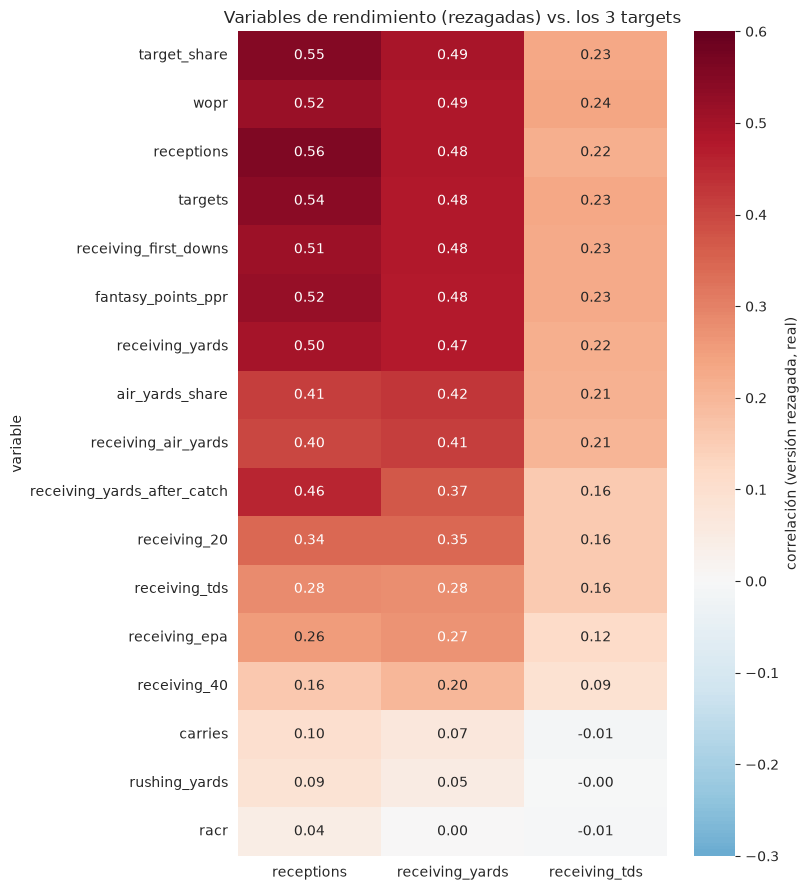

In [3]:
COLS_RENDIMIENTO = [
    "receptions", "receiving_yards", "receiving_tds", "targets", "target_share",
    "air_yards_share", "wopr", "receiving_air_yards", "receiving_yards_after_catch",
    "receiving_first_downs", "receiving_epa", "racr", "receiving_20", "receiving_40",
    "carries", "rushing_yards", "fantasy_points_ppr",
]
con_feats = features.agregar_promedios_jugador(wr, COLS_RENDIMIENTO, id_col="player_id")

filas = []
for col in COLS_RENDIMIENTO:
    fila = {"variable": col}
    for t in TARGETS:
        fila[t] = con_feats[f"{col}_season_avg"].corr(con_feats[t])
    filas.append(fila)
tabla_rendimiento = pd.DataFrame(filas).set_index("variable").sort_values("receiving_yards", ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(tabla_rendimiento, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.6, ax=ax,
            cbar_kws={"label": "correlación (versión rezagada, real)"})
ax.set_title("Variables de rendimiento (rezagadas) vs. los 3 targets")
plt.tight_layout()
plt.show()

**Lecturas nuevas, no vistas antes en este proyecto:**

- `carries`/`rushing_yards` (uso como corredor, ej. jet sweeps) — **prácticamente sin
  correlación** (0.10, 0.07, e incluso -0.01 para touchdowns). Un WR con jugadas de carrera no
  predice mejor su propio rendimiento como receptor. No vale la pena como feature para este
  problema específico, aunque el dato exista y sea real (13% de las semanas activas tienen al
  menos un acarreo).
- `racr` (eficiencia de conversión de yardas aéreas) — **básicamente cero** en los 3 targets.
  Tiene sentido: mide eficiencia por jugada, no volumen de oportunidad, y son las variables de
  volumen (`target_share`, `targets`, `receptions`) las que sí predicen.
- `receiving_first_downs` y `fantasy_points_ppr` rezagados quedan en el grupo de arriba, muy
  cerca de `target_share` — no se habían considerado antes como candidatas.
- Touchdowns, columna a columna, tiene la correlación más baja en **cada una** de las 17
  variables — no es que falte la variable correcta, es el target en sí el que es difícil.

## 2. Las 4 ventanas (`last3`, `last5`, `season`, `career`) — para los 3 targets, no solo yardas

Esto es lo que se pidió explícitamente verificar: no asumir que el patrón de yardas se repite
igual en recepciones y touchdowns.

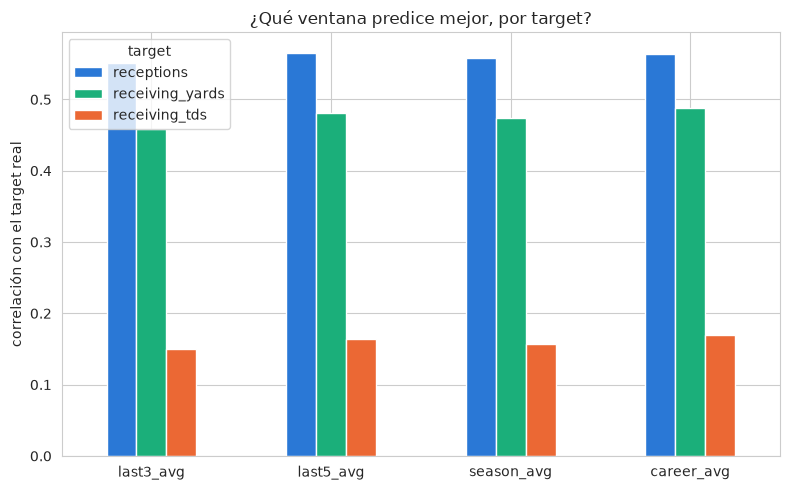

            receptions  receiving_yards  receiving_tds
last3_avg       0.5518           0.4579         0.1506
last5_avg       0.5658           0.4808         0.1645
season_avg      0.5581           0.4745         0.1576
career_avg      0.5642           0.4874         0.1691


In [4]:
ventanas = ["last3_avg", "last5_avg", "season_avg", "career_avg"]
tabla_ventanas = pd.DataFrame({
    t: [con_feats[f"{t}_{v}"].corr(con_feats[t]) for v in ventanas]
    for t in TARGETS
}, index=ventanas)

fig, ax = plt.subplots(figsize=(8, 5))
tabla_ventanas.plot(kind="bar", ax=ax, color=[AZUL, VERDE, NARANJA])
ax.set_ylabel("correlación con el target real")
ax.set_title("¿Qué ventana predice mejor, por target?")
ax.legend(title="target")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(tabla_ventanas.round(4))

**El patrón se repite en los 3 targets, no solo en yardas**: `last3` es consistentemente la
ventana más débil de las 4 (más ruido, menos partidos para promediar), y `career`/`last5` quedan
arriba, muy cerca entre sí. La diferencia es pequeña (2-3 puntos porcentuales de correlación) —
no alcanza para "decidir" la ventana solo con esto, pero sí confirma que no hay que asumir que
`last3` es automáticamente la mejor opción solo porque es la que ya traía el pipeline heredado.
La decisión final se deja para la comparación de modelos en Fase 5, con los 3 targets, no solo
yardas.

## 3. Contexto conocido de antemano — edad, draft, equipo, descanso, superficie

A diferencia de la sección 1, estas variables no necesitan rezago: se conocen antes de que se
juegue el partido (la edad de alguien, en qué pick lo draftearon, si el partido es de división).

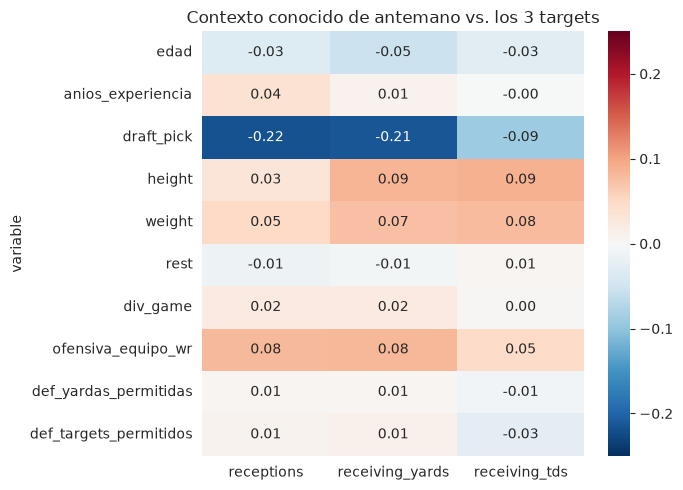

In [5]:
wr_ctx = con_feats.merge(
    jugadores[["gsis_id", "birth_date", "rookie_season", "draft_pick", "height", "weight"]],
    left_on="player_id", right_on="gsis_id", how="left"
)
ref = pd.to_datetime(wr_ctx["season"].astype(str) + "-09-01")
wr_ctx["edad"] = (ref - wr_ctx["birth_date"]).dt.days / 365.25
wr_ctx["anios_experiencia"] = wr_ctx["season"] - wr_ctx["rookie_season"]

cal_home = calendario[["season", "week", "home_team", "home_rest", "div_game", "roof", "surface"]].rename(columns={"home_team": "team", "home_rest": "rest"})
cal_away = calendario[["season", "week", "away_team", "away_rest", "div_game", "roof", "surface"]].rename(columns={"away_team": "team", "away_rest": "rest"})
cal_long = pd.concat([cal_home, cal_away], ignore_index=True)
wr_ctx = wr_ctx.merge(cal_long, on=["season", "week", "team"], how="left")

of_semana = wr.groupby(["season", "team", "week"])["receiving_yards"].sum().reset_index()
of_semana["ofensiva_equipo_wr"] = of_semana.groupby(["season", "team"])["receiving_yards"].transform(lambda s: s.shift(1).expanding().mean())
wr_ctx = wr_ctx.merge(of_semana[["season", "team", "week", "ofensiva_equipo_wr"]], on=["season", "team", "week"], how="left")

def_semana = wr.groupby(["season", "opponent_team", "week"])[["receiving_yards", "targets"]].sum().reset_index()
def_semana["def_yardas_permitidas"] = def_semana.groupby(["season", "opponent_team"])["receiving_yards"].transform(lambda s: s.shift(1).expanding().mean())
def_semana["def_targets_permitidos"] = def_semana.groupby(["season", "opponent_team"])["targets"].transform(lambda s: s.shift(1).expanding().mean())
wr_ctx = wr_ctx.merge(
    def_semana[["season", "opponent_team", "week", "def_yardas_permitidas", "def_targets_permitidos"]],
    on=["season", "opponent_team", "week"], how="left"
)

vars_contexto = ["edad", "anios_experiencia", "draft_pick", "height", "weight", "rest", "div_game",
                  "ofensiva_equipo_wr", "def_yardas_permitidas", "def_targets_permitidos"]
tabla_contexto = pd.DataFrame({
    "variable": vars_contexto,
    **{t: [wr_ctx[c].corr(wr_ctx[t]) for c in vars_contexto] for t in TARGETS}
}).set_index("variable")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(tabla_contexto, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.25, vmax=0.25, ax=ax)
ax.set_title("Contexto conocido de antemano vs. los 3 targets")
plt.tight_layout()
plt.show()

**El hallazgo más importante de esta sección: `draft_pick` correlaciona más que la edad o la
experiencia** (-0.22 recepciones, -0.21 yardas — negativo porque un pick más bajo/temprano es
"mejor"). Nunca se había considerado esta variable en el proyecto. Edad y experiencia siguen
prácticamente en cero (ya se sabía que su relación real es no lineal, no que no exista relación).

**Confirmado con más profundidad que antes**: la dureza defensiva del rival, calculada ahora
*dentro de la misma temporada* (no solo comparando entre años como en `06_eda_equipos`), sigue
sin correlación real — ni contra yardas permitidas (0.006) ni contra **targets permitidos**
(0.009), que es justo lo que se pidió verificar. No es un problema de cómo se calculó antes
(año contra año); el rival simplemente no predice la producción individual de un WR, con
ninguna de las dos formas de medirlo.

In [6]:
print(wr_ctx.groupby("roof", observed=True)["receiving_yards"].agg(["mean", "count"]))
print()
print(wr_ctx.groupby("surface", observed=True)["receiving_yards"].agg(["mean", "count"]))

               mean  count
roof                      
closed    39.223724    666
dome      41.152258    775
outdoors  36.022214   2746

                 mean  count
surface                     
            43.080000     25
a_turf      32.536232    138
astroturf   34.205882    136
fieldturf   40.345000   1000
grass       35.394089   2233
matrixturf  43.571072    401
sportturf   38.826772    254


Jugar bajo techo (domo: 41.2, cerrado: 39.2) rinde algo más que al aire libre (36.0) — pequeño
pero consistente con la intuición de que el clima real afecta el juego de pase. La superficie
muestra más variación (32.5 a 43.6), pero mezclada con qué equipos juegan en cuál superficie —
no se puede separar el efecto de la superficie del efecto del equipo con este análisis.

## 4. La identidad del quarterback — algo que nunca se había mirado en este proyecto

Se prueban dos cosas distintas: si la **calidad continua** del QB (su EPA de pase, acumulado en
la temporada) importa, y si un **cambio** de quarterback titular golpea la producción del
receptor — son preguntas distintas.

correlacion calidad continua del QB (EPA rezagado) vs receptions: 0.027
correlacion calidad continua del QB (EPA rezagado) vs receiving_yards: 0.049
correlacion calidad continua del QB (EPA rezagado) vs receiving_tds: 0.032


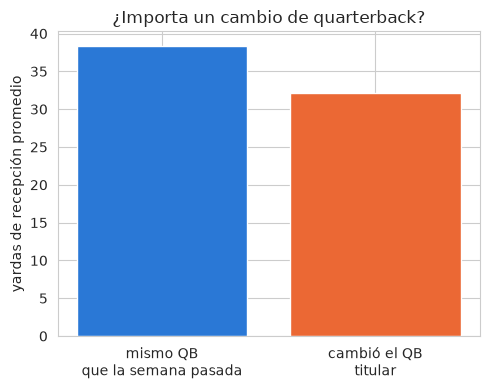

                mean  count
cambio_qb                  
False      38.372669   3593
True       32.087542    594


In [7]:
qb = stats[stats["position"] == "QB"][["season", "week", "team", "player_display_name", "passing_epa", "attempts"]].copy()
qb_starter = qb.sort_values("attempts", ascending=False).drop_duplicates(subset=["season", "week", "team"])
qb_starter = qb_starter.rename(columns={"player_display_name": "qb_name", "passing_epa": "qb_passing_epa"})
qb_starter["qb_epa_season_avg"] = qb_starter.groupby(["team", "season"])["qb_passing_epa"].transform(lambda s: s.shift(1).expanding().mean())

wr_qb = wr_ctx.merge(qb_starter[["season", "week", "team", "qb_name", "qb_epa_season_avg"]], on=["season", "week", "team"], how="left")
for t in TARGETS:
    print(f"correlacion calidad continua del QB (EPA rezagado) vs {t}: {wr_qb['qb_epa_season_avg'].corr(wr_qb[t]):.3f}")

wr_qb_sorted = wr_qb.sort_values(["player_id", "season", "week"])
wr_qb_sorted["qb_anterior"] = wr_qb_sorted.groupby("player_id")["qb_name"].shift(1)
wr_qb_sorted["cambio_qb"] = (wr_qb_sorted["qb_name"] != wr_qb_sorted["qb_anterior"]) & wr_qb_sorted["qb_anterior"].notna()

fig, ax = plt.subplots(figsize=(5, 4))
resumen_cambio = wr_qb_sorted.groupby("cambio_qb")["receiving_yards"].mean()
ax.bar(["mismo QB\nque la semana pasada", "cambió el QB\ntitular"], resumen_cambio.values, color=[AZUL, NARANJA])
ax.set_ylabel("yardas de recepción promedio")
ax.set_title("¿Importa un cambio de quarterback?")
plt.tight_layout()
plt.show()

print(wr_qb_sorted.groupby("cambio_qb")["receiving_yards"].agg(["mean", "count"]))

**Resultado con dos caras, y hay que ser honesto sobre las dos**: la calidad continua del QB
(su EPA acumulado) casi no correlaciona con la producción del receptor (0.03-0.05) — parecido al
hallazgo de Vegas: el uso reciente del jugador ya captura la mayor parte de lo que importa. Pero
un **cambio real** de quarterback titular sí golpea: 32.1 yardas promedio contra 38.4 cuando se
mantiene el mismo — una caída real de ~16%, sobre 594 casos reales de cambio. No es lo mismo "un
QB algo mejor que otro" (no importa mucho) que "se acaba de lesionar el titular y entra el
suplente" (sí importa, y bastante). Vale la pena explorar un indicador de "cambio reciente de QB"
en Fase 4, no un continuo de calidad de QB.

## 5. Multicolinealidad — ¿las variables candidatas se pisan entre sí?

Esto importa en particular para un modelo lineal (Ridge): variables muy correlacionadas entre sí
hacen inestables sus coeficientes, aunque cada una por separado se vea bien en la sección 1.

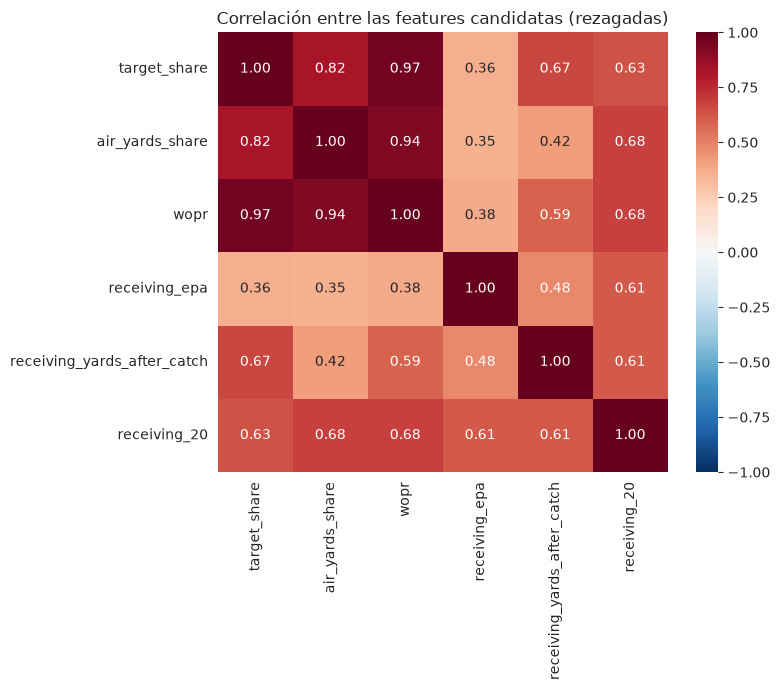

In [8]:
cols_finales = [f"{c}_season_avg" for c in
                ["target_share", "air_yards_share", "wopr", "receiving_epa", "receiving_yards_after_catch", "receiving_20"]]
matriz = con_feats[cols_finales].corr()

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=[c.replace("_season_avg", "") for c in cols_finales],
            yticklabels=[c.replace("_season_avg", "") for c in cols_finales])
ax.set_title("Correlación entre las features candidatas (rezagadas)")
plt.tight_layout()
plt.show()

**`target_share`, `air_yards_share` y `wopr` están fuertemente correlacionadas entre sí (0.82 a
0.97)** — tiene una explicación exacta, no es casualidad: `wopr` está definido como una
combinación ponderada de las otras dos. Usar las 3 juntas en un modelo lineal es redundante y
puede desestabilizar sus coeficientes. `receiving_epa` es la más independiente del grupo (0.35 a
0.48 con las demás) — aporta información distinta, no solo una versión reescalada de lo mismo.
**Acción para Fase 4**: para Ridge, probar con una sola de las 3 (`wopr`, que ya las combina) más
`receiving_epa`, en vez de meter las 3; para XGBoost/Random Forest la redundancia importa menos,
pero tampoco suma nada meterlas todas.

## Cierre

Comparado con los notebooks 06-07 (guiados por hipótesis puntuales), esto es lo que cambia con una revisión sistemática de las 3 fuentes completas:

**Nuevo, no visto antes:**
- `draft_pick` correlaciona más que edad/experiencia — candidato real para Fase 4.
- Un cambio de QB titular golpea la producción (~16% menos yardas); la calidad continua del QB,
  casi no importa — matiz que no se había explorado.
- `target_share`/`air_yards_share`/`wopr` son casi la misma información repetida 3 veces — cuidado
  con Ridge.
- Jet sweeps/acarreos de un WR no predicen nada de su propio rendimiento como receptor.
- `racr` (eficiencia) no aporta — solo el volumen de oportunidad predice.

**Confirmado con más rigor que antes:**
- La dureza defensiva del rival no importa, ni en yardas ni en targets permitidos, ni comparando
  entre temporadas ni calculada dentro de la misma temporada.
- El patrón "`last3` es la ventana más débil" se repite en los 3 targets, no solo en yardas.
- Touchdowns tiene la correlación más baja contra **cualquier** variable probada — no es un
  problema de features faltantes, es el target mismo.

Notebook anterior: [`07_eda_equipos.ipynb`](07_eda_equipos.ipynb) · Siguiente: [`09_eda_jugador_destacado.ipynb`](09_eda_jugador_destacado.ipynb)